<a href="https://colab.research.google.com/github/gunavathibaskaran170/AI-project-/blob/main/Insurance_Analysis_using_DecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [172]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("/content/drive/MyDrive/DATASET /insurance_claims.csv")
df.isnull().sum()
df.head()

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN


In [173]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 40 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   months_as_customer           1000 non-null   int64  
 1   age                          1000 non-null   int64  
 2   policy_number                1000 non-null   int64  
 3   policy_bind_date             1000 non-null   object 
 4   policy_state                 1000 non-null   object 
 5   policy_csl                   1000 non-null   object 
 6   policy_deductable            1000 non-null   int64  
 7   policy_annual_premium        1000 non-null   float64
 8   umbrella_limit               1000 non-null   int64  
 9   insured_zip                  1000 non-null   int64  
 10  insured_sex                  1000 non-null   object 
 11  insured_education_level      1000 non-null   object 
 12  insured_occupation           1000 non-null   object 
 13  insured_hobbies    

In [174]:
df.shape

(1000, 40)

In [175]:
df.replace("?", np.nan, inplace=True)
df.replace("Y", "Yes", inplace=True)
df.replace("N", "No", inplace=True)

In [176]:
df.head(20)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Yes,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,NaN,5070,780,780,3510,Mercedes,E400,2007,Yes,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,No,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Yes,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,No,NaN
5,256,39,104594,2006-10-12,OH,250/500,1000,1351.10,0,478456,...,NO,64100,6410,6410,51280,Saab,95,2003,Yes,NaN
6,137,34,413978,2000-06-04,IN,250/500,1000,1333.35,0,441716,...,NaN,78650,21450,7150,50050,Nissan,Pathfinder,2012,No,NaN
7,165,37,429027,1990-02-03,IL,100/300,1000,1137.03,0,603195,...,YES,51590,9380,9380,32830,Audi,A5,2015,No,NaN
8,27,33,485665,1997-02-05,IL,100/300,500,1442.99,0,601734,...,YES,27700,2770,2770,22160,Toyota,Camry,2012,No,NaN
9,212,42,636550,2011-07-25,IL,100/300,500,1315.68,0,600983,...,NaN,42300,4700,4700,32900,Saab,92x,1996,No,NaN


# **Handling the Nan value**

In [177]:
from sklearn.impute import SimpleImputer
si=SimpleImputer(strategy='most_frequent')
df[['collision_type','police_report_available','fraud_reported','property_damage']]=si.fit_transform(df[['collision_type','police_report_available','fraud_reported','property_damage']])

In [178]:
df.head(20)

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Yes,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,NO,5070,780,780,3510,Mercedes,E400,2007,Yes,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,No,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Yes,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,No,NaN
5,256,39,104594,2006-10-12,OH,250/500,1000,1351.10,0,478456,...,NO,64100,6410,6410,51280,Saab,95,2003,Yes,NaN
6,137,34,413978,2000-06-04,IN,250/500,1000,1333.35,0,441716,...,NO,78650,21450,7150,50050,Nissan,Pathfinder,2012,No,NaN
7,165,37,429027,1990-02-03,IL,100/300,1000,1137.03,0,603195,...,YES,51590,9380,9380,32830,Audi,A5,2015,No,NaN
8,27,33,485665,1997-02-05,IL,100/300,500,1442.99,0,601734,...,YES,27700,2770,2770,22160,Toyota,Camry,2012,No,NaN
9,212,42,636550,2011-07-25,IL,100/300,500,1315.68,0,600983,...,NO,42300,4700,4700,32900,Saab,92x,1996,No,NaN





>**Data type Count - dtype.value_counts()**





In [179]:
df.dtypes.value_counts()


,count
object,21
int64,17
float64,2


# **Droppin unwanted Row**

In [180]:
df.drop(columns=['_c39','policy_number','incident_location','policy_bind_date','incident_date'], inplace=True)

# **Label Encoding**

In [181]:
from sklearn.preprocessing import LabelEncoder
le =LabelEncoder()
for col in df.columns:
  if df[col].dtype=='object':
    df[col]=le.fit_transform(df[col].astype(str))
df

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,insured_sex,insured_education_level,...,witnesses,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported
0,328,48,2,1,1000,1406.91,0,466132,1,4,...,2,1,71610,6510,13020,52080,10,1,2004,1
1,228,42,1,1,2000,1197.22,5000000,468176,1,4,...,0,0,5070,780,780,3510,8,12,2007,1
2,134,29,2,0,2000,1413.14,5000000,430632,0,6,...,3,0,34650,7700,3850,23100,4,30,2007,0
3,256,41,0,1,2000,1415.74,6000000,608117,0,6,...,2,0,63400,6340,6340,50720,3,34,2014,1
4,228,44,0,2,1000,1583.91,6000000,610706,1,0,...,1,0,6500,1300,650,4550,0,31,2009,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,2,2,1000,1310.80,0,431289,0,5,...,1,0,87200,17440,8720,61040,6,6,2006,0
996,285,41,0,0,1000,1436.79,0,608177,0,6,...,3,0,108480,18080,18080,72320,13,28,2015,0
997,130,34,2,1,500,1383.49,3000000,442797,0,5,...,3,1,67500,7500,7500,52500,11,19,1996,0
998,458,62,0,2,2000,1356.92,5000000,441714,1,0,...,1,1,46980,5220,5220,36540,1,5,1998,0


In [182]:
df.dtypes.value_counts()

,count
int64,34
float64,1


In [183]:
df.isnull().sum()

,0
months_as_customer,0
age,0
policy_state,0
policy_csl,0
policy_deductable,0
policy_annual_premium,0
umbrella_limit,0
insured_zip,0
insured_sex,0
insured_education_level,0


# **Finding the Correlation**

<Axes: >

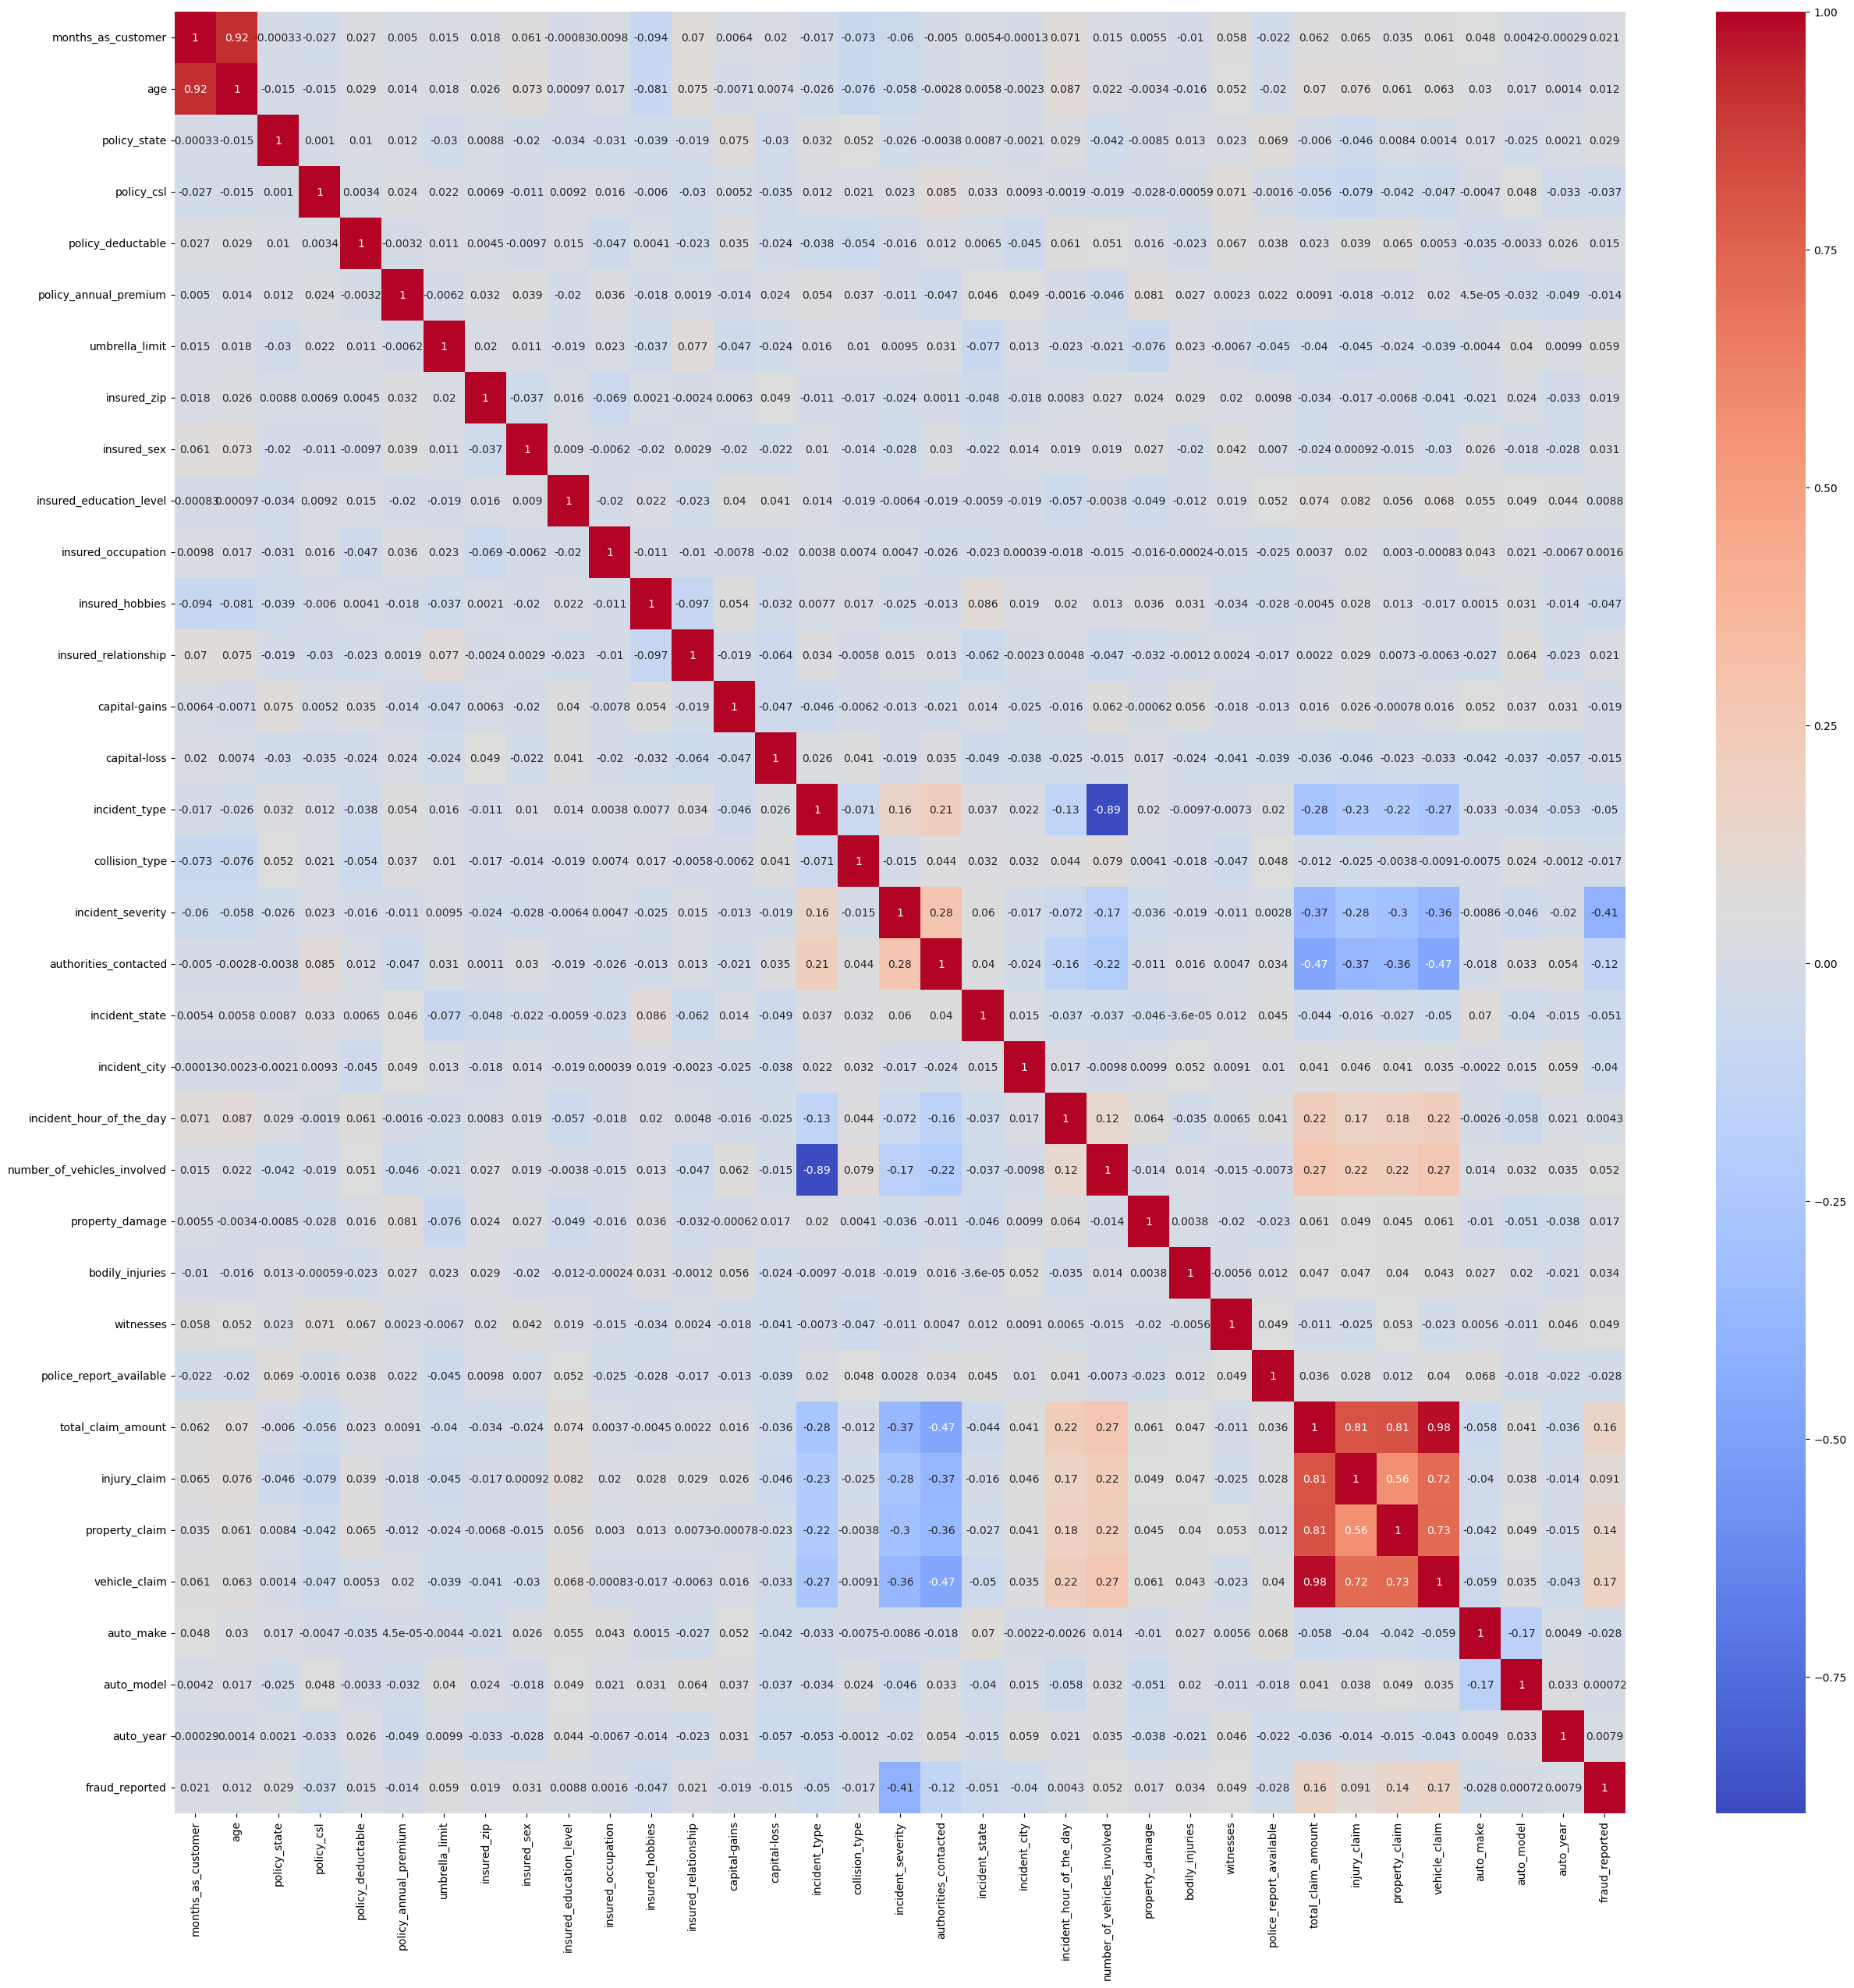

In [184]:
corr=df.corr()
plt.figure(figsize=(30,30))
sns.heatmap(corr, annot=True , cmap='coolwarm') # annot means display the values

In [185]:
target_corr= corr['fraud_reported']
print(target_corr.sort_values(ascending=False))

fraud_reported                 1.000000
vehicle_claim                  0.170049
total_claim_amount             0.163651
property_claim                 0.137835
injury_claim                   0.090975
umbrella_limit                 0.058622
number_of_vehicles_involved    0.051839
witnesses                      0.049497
bodily_injuries                0.033877
insured_sex                    0.030873
policy_state                   0.029432
insured_relationship           0.021043
months_as_customer             0.020544
insured_zip                    0.019368
property_damage                0.017202
policy_deductable              0.014817
age                            0.012143
insured_education_level        0.008808
auto_year                      0.007928
incident_hour_of_the_day       0.004316
insured_occupation             0.001564
auto_model                     0.000720
policy_annual_premium         -0.014480
capital-loss                  -0.014863
collision_type                -0.017315


# **Defining X values and Y values**

Yes — in MOST real datasets, both:

highly positive correlated features
highly negative correlated features

can be useful.

Because ML cares about:

relationship strength with target

NOT whether the direction is positive or negative.

***.shape[0]:*** Represents the first dimension (rows).

***.shape[1]:*** Represents the second dimension (columns).

In [169]:
select_col=target_corr[abs(target_corr)>0.05].index
select_col=select_col.drop('fraud_reported')
select_col.value_counts().sum()
X=df[select_col]
y=df['fraud_reported']


0    1
1    1
2    0
3    1
4    0
Name: fraud_reported, dtype: int64


**Applying and checking for the outliers**

In [171]:
num_col =X.select_dtypes(include=['int64','float64']).columns
for out in num_col:
  q1=X[out].quantile(0.25)
  q3=X[out].quantile(0.75)
  IQR=q3-q1
  lower= q1-1.5*IQR
  upper= q3+ 1.5*IQR
  outliers= X[(X[out]<lower)|(X[out]>upper)]
print(out,":",outliers.shape[0])

vehicle_claim : 0


In [186]:
from scipy.stats.mstats import winsorize
win_col=['umbrella_limit','total_claim_amount','property_claim','vehicle_claim']
for win in win_col:
  X[win]=winsorize(X[win],limits=[0.05,0.05])


/tmp/ipykernel_2587/3059266745.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X[win]=winsorize(X[win],limits=[0.05,0.05])


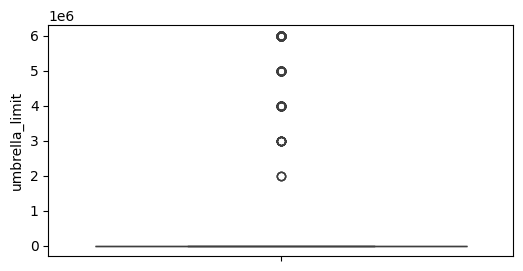

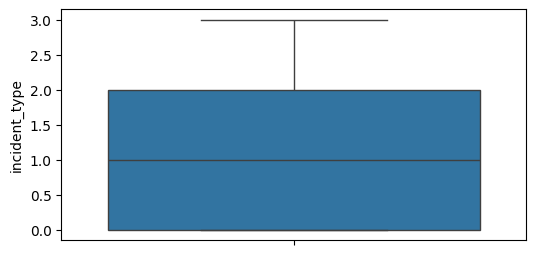

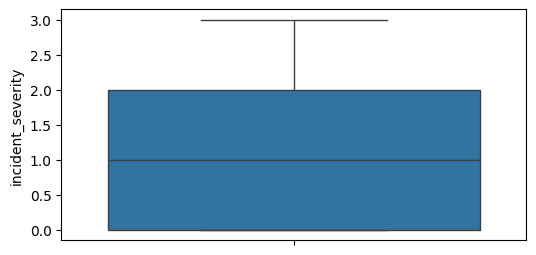

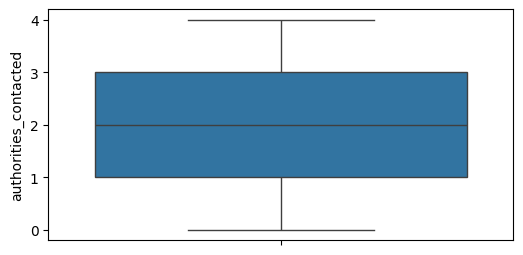

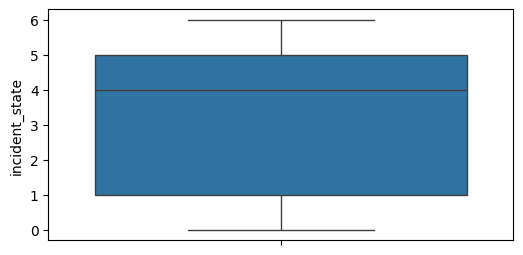

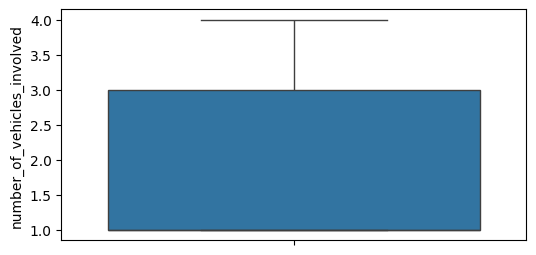

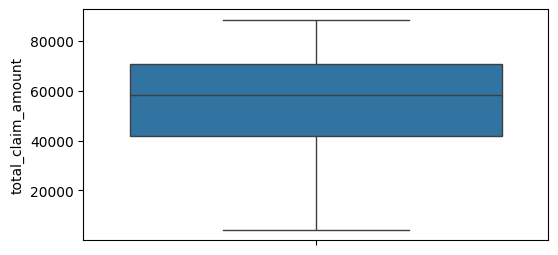

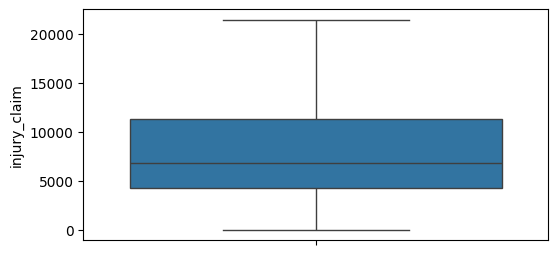

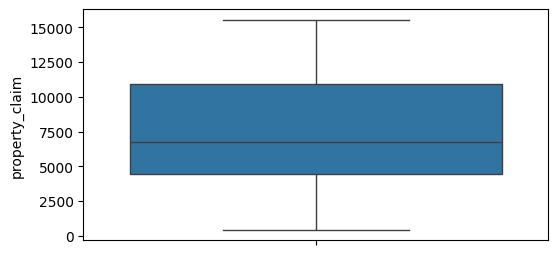

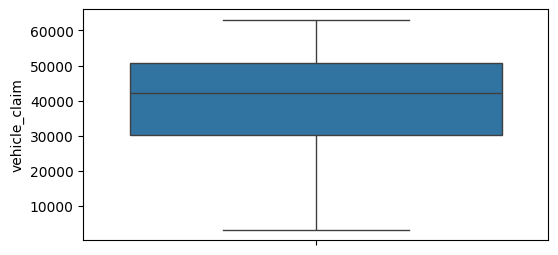

In [196]:
for box in num_col:
  plt.figure(figsize=(6,3))
  sns.boxplot(X[box])

In [188]:
X.isnull().sum()

,0
umbrella_limit,0
incident_type,0
incident_severity,0
authorities_contacted,0
incident_state,0
number_of_vehicles_involved,0
total_claim_amount,0
injury_claim,0
property_claim,0
vehicle_claim,0


In [195]:
from scipy.stats import zscore
z_score=zscore(X[['umbrella_limit']]) #common rule :z>3
X[np.abs(z_score)>3]

,umbrella_limit,incident_type,incident_severity,authorities_contacted,incident_state,number_of_vehicles_involved,total_claim_amount,injury_claim,property_claim,vehicle_claim


In [197]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [221]:
from sklearn.tree import DecisionTreeClassifier
model =DecisionTreeClassifier(criterion='entropy',max_depth=3)
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [222]:
y_pred =model.predict(X_test)

In [223]:
from sklearn.metrics import accuracy_score,classification_report
print("Accuracy : ",accuracy_score(y_test,y_pred))
print("Classification report :",classification_report(y_test,y_pred))

Accuracy :  0.78
Classification report :               precision    recall  f1-score   support

           0       0.86      0.83      0.85       145
           1       0.59      0.65      0.62        55

    accuracy                           0.78       200
   macro avg       0.73      0.74      0.73       200
weighted avg       0.79      0.78      0.78       200



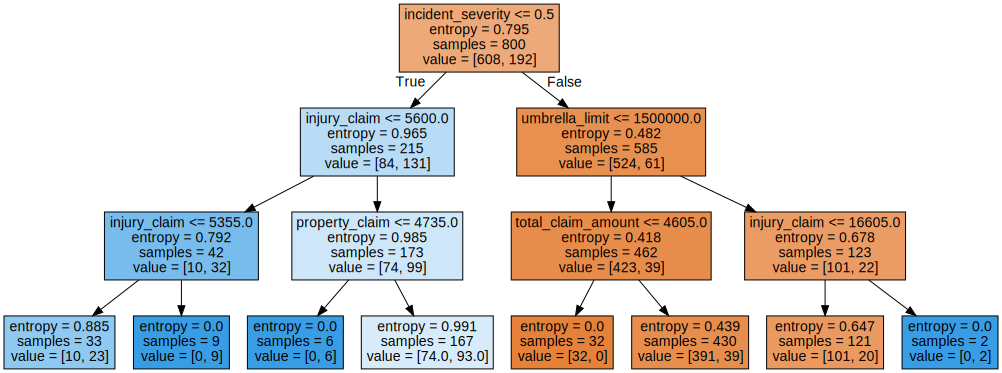

In [224]:
from sklearn.tree import export_graphviz
import graphviz
graphviz.Source(export_graphviz(model,feature_names=X.columns,filled=True))